# Data Quality Assessment: Sprocket Central (Bike Retailer)

**Context:** Sprocket Central Pty Ltd, a bike and accessories retailer, wants to use its customer data to target high-value customers. Before any modelling, KPMG's analytics team was asked to assess the quality of the three datasets and recommend how to fix the issues.

**Approach:** each table is checked against standard data quality dimensions. Every issue is logged with the number of rows affected and a recommended fix, so the client can see exactly what was found and what to change.

| Dimension | Question |
|---|---|
| Completeness | Are values missing? |
| Consistency | Is the same thing written the same way across rows and tables? |
| Accuracy / Validity | Are values plausible and in the right format? |
| Uniqueness | Are identifiers duplicated? |
| Integrity | Do keys match across tables? |
| Relevancy / Currency | Is every column useful and up to date? |

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4)

FILE = "data/KPMG_VI_New_raw_data_update_final.xlsx"
transactions = pd.read_excel(FILE, sheet_name="Transactions")
demographic = pd.read_excel(FILE, sheet_name="CustomerDemographic")
address = pd.read_excel(FILE, sheet_name="CustomerAddress")

for name, df in [("Transactions", transactions), ("CustomerDemographic", demographic), ("CustomerAddress", address)]:
    print(f"{name:<20} {df.shape[0]:>6,} rows x {df.shape[1]} columns")

Transactions         20,000 rows x 13 columns
CustomerDemographic   4,000 rows x 13 columns
CustomerAddress       3,999 rows x 6 columns


Every issue is appended to a single log, which is summarised at the end.

In [2]:
issues = []

def log(table, column, dimension, issue, rows, fix):
    issues.append(dict(table=table, column=column, dimension=dimension,
                       issue=issue, rows_affected=int(rows), recommendation=fix))

## 2. Completeness: missing values

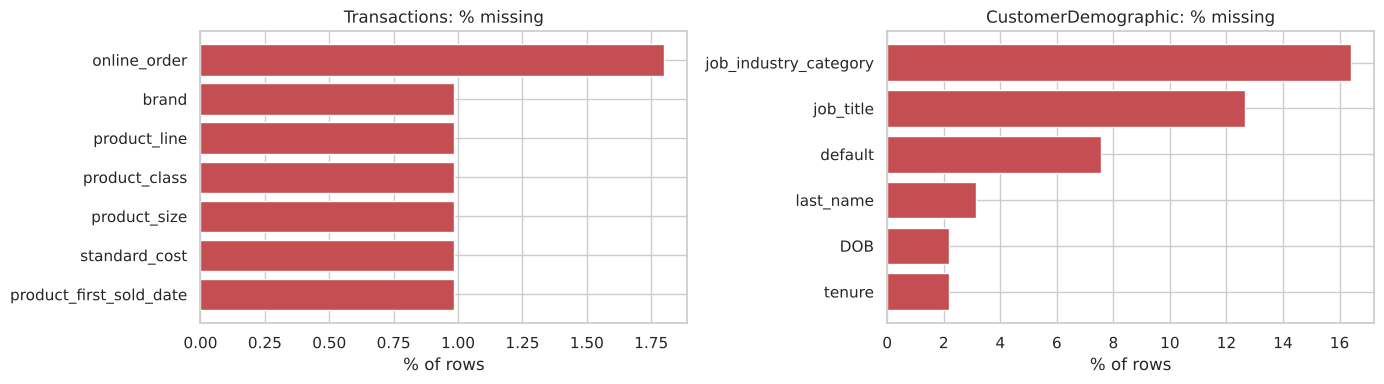

CustomerAddress missing values: 0


In [3]:
def missing_report(df):
    m = df.isna().sum()
    return (pd.DataFrame({"missing": m, "pct": m / len(df)})
              .query("missing > 0")
              .sort_values("missing", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, df) in zip(axes, [("Transactions", transactions), ("CustomerDemographic", demographic)]):
    r = missing_report(df)
    ax.barh(r.index, r["pct"] * 100, color="C3")
    ax.set(title=f"{name}: % missing", xlabel="% of rows")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("CustomerAddress missing values:", address.isna().sum().sum())

In [4]:
missing_report(transactions)

,missing,pct
online_order,360,0.01800
brand,197,0.00985
product_line,197,0.00985
product_class,197,0.00985
product_size,197,0.00985
standard_cost,197,0.00985
product_first_sold_date,197,0.00985


The 197 missing product fields are in the same rows: brand, product line, class, size, cost and first-sold date are all missing together.

In [5]:
product_cols = ["brand", "product_line", "product_class", "product_size", "standard_cost", "product_first_sold_date"]
print("Rows where all product fields are missing together:",
      transactions[product_cols].isna().all(axis=1).sum())

log("Transactions", "brand + 5 product columns", "Completeness",
    "Product attributes missing (same rows)", transactions["brand"].isna().sum(),
    "Look up attributes by product_id from the product master; otherwise exclude from product-level analysis")
log("Transactions", "online_order", "Completeness", "Missing order channel",
    transactions["online_order"].isna().sum(),
    "Keep as 'Unknown' category rather than dropping the sale")

Rows where all product fields are missing together: 197


In [6]:
missing_report(demographic)

,missing,pct
job_industry_category,656,0.16400
job_title,506,0.12650
default,302,0.07550
last_name,125,0.03125
DOB,87,0.02175
tenure,87,0.02175


In [7]:
log("CustomerDemographic", "job_industry_category", "Completeness", "Missing industry",
    demographic["job_industry_category"].isna().sum(), "Label as 'Unknown'; ask client to capture at sign-up")
log("CustomerDemographic", "job_title", "Completeness", "Missing job title",
    demographic["job_title"].isna().sum(), "Label as 'Unknown'")
log("CustomerDemographic", "last_name", "Completeness", "Missing last name",
    demographic["last_name"].isna().sum(), "Not needed for modelling; flag for the CRM team")
dob_tenure_missing = demographic["DOB"].isna() & demographic["tenure"].isna()
log("CustomerDemographic", "DOB, tenure", "Completeness", "DOB and tenure missing (same rows)",
    dob_tenure_missing.sum(), "Exclude from age-based segmentation or impute with the median by segment")
print("Rows with both DOB and tenure missing:", dob_tenure_missing.sum())

Rows with both DOB and tenure missing: 87


## 3. Consistency: same value, different spellings

In [8]:
demographic["gender"].value_counts()

gender
Female    2037
Male      1872
U           88
F            1
Femal        1
M            1
Name: count, dtype: int64

In [9]:
bad_gender = demographic["gender"].isin(["F", "Femal", "M"])
log("CustomerDemographic", "gender", "Consistency", "Gender coded as F / Femal / M alongside Female / Male",
    bad_gender.sum(), "Map to Female / Male")
log("CustomerDemographic", "gender", "Completeness", "Gender 'U' (unknown)",
    (demographic["gender"] == "U").sum(), "Keep as 'Unknown'")
address["state"].value_counts()

state
NSW                2054
VIC                 939
QLD                 838
New South Wales      86
Victoria             82
Name: count, dtype: int64

In [10]:
long_states = address["state"].isin(["New South Wales", "Victoria"])
log("CustomerAddress", "state", "Consistency", "Full state names mixed with abbreviations",
    long_states.sum(), "Map New South Wales -> NSW, Victoria -> VIC")
demographic["job_industry_category"].value_counts()

job_industry_category
Manufacturing         799
Financial Services    774
Health                602
Retail                358
Property              267
IT                    223
Entertainment         136
Argiculture           113
Telecommunications     72
Name: count, dtype: int64

In [11]:
log("CustomerDemographic", "job_industry_category", "Accuracy", "Typo 'Argiculture'",
    (demographic["job_industry_category"] == "Argiculture").sum(), "Rename to 'Agriculture'")

## 4. Accuracy and validity

### 4.1 Date of birth

In [12]:
dob = pd.to_datetime(demographic["DOB"], errors="coerce")
print("Earliest DOBs:")
print(dob.nsmallest(3).dt.date.to_string())

Earliest DOBs:
33      1843-12-21
719     1931-10-23
1091    1935-08-22


In [13]:
REFERENCE_DATE = pd.Timestamp("2017-12-31")   # end of the transaction period
demographic["age"] = (REFERENCE_DATE - dob).dt.days / 365.25

too_old = demographic["age"] > 100
log("CustomerDemographic", "DOB", "Accuracy", "Implausible DOB (born 1843, age > 170)",
    too_old.sum(), "Treat as missing and confirm with client")

Age is computed at the end of the data period (31 Dec 2017), not today's date. Otherwise the ages would change every time the notebook is run.

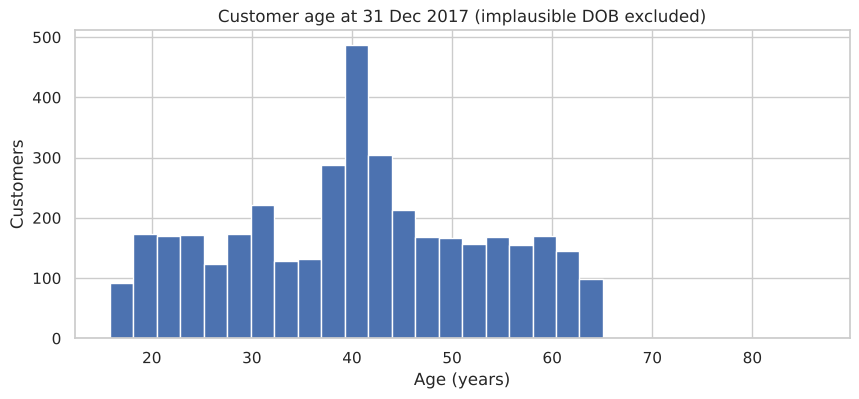

Skewness: 0.01   Excess kurtosis: -0.80


In [14]:
fig, ax = plt.subplots()
demographic.loc[~too_old, "age"].plot.hist(bins=30, ax=ax, color="C0", edgecolor="white")
ax.set(title="Customer age at 31 Dec 2017 (implausible DOB excluded)", xlabel="Age (years)", ylabel="Customers")
plt.show()

valid_age = demographic.loc[~too_old, "age"].dropna()
print(f"Skewness: {valid_age.skew():.2f}   Excess kurtosis: {stats.kurtosis(valid_age):.2f}")

The age distribution is roughly symmetric (skewness ≈ 0) and flatter than a normal distribution (negative excess kurtosis, so platykurtic).

### 4.2 Columns with unusable content

In [15]:
demographic["default"].sample(8, random_state=1).tolist()

['TÌÌ\xadÌºÌºoÍ Ì·iÌ²Ì¬ÍÌªÍnÌÌÍvÍÌÌÌÌ¦oÌ¶ÌÌ°Ì\xa0keÍÍÌ®ÌºÌªÌ¹Ì±Ì¤ ÌtÍÌÍÌ³Ì£Ì»ÌªhÌ¼ÍÌ²Ì¦Ì³ÌÌ²eÍÌ£Ì°Ì¦Ì¬Í Ì¢Ì¼Ì»Ì±ÌhÍÍÍÍÌÌ£Ì²iÌ¦Ì²Ì£Ì°Ì¤vÌ»ÍeÌºÌ\xadÌ³ÌªÌ°-mÌ¢iÍnÌÌºÌÌ²Ì¯Ì°dÌµÌ¼ÌÍÌ©Ì¼ÌÌ³ ÌÌ¥Ì±Ì³Ì\xadrÌÌÌeÍpÍ\xa0rÌ¼ÌÌ»Ì\xadÌeÍÌºÌ\xa0Ì£sÌ',
 'â£',
 '<>?:"{}|_+',
 '0/0',
 'ã½à¼¼àºÙÍàºà¼½ï¾ ã½à¼¼àºÙÍàºà¼½ï¾',
 'ì¬íê³¼íì ì´íì°êµ¬ì',
 'Î©âÃ§ââ«ËÂµâ¤â¥Ã·',
 nan]

In [16]:
log("CustomerDemographic", "default", "Relevancy", "Column contains garbage strings (e.g. injected code, emojis)",
    len(demographic), "Drop the column")

### 4.3 Data types

In [17]:
print("product_first_sold_date dtype:", transactions["product_first_sold_date"].dtype)
print(transactions["product_first_sold_date"].dropna().head(3).tolist())

product_first_sold_date dtype: float64
[41245.0, 41701.0, 36361.0]


In [18]:
transactions["product_first_sold_date"] = pd.to_datetime(
    transactions["product_first_sold_date"], origin="1899-12-30", unit="D"
)
log("Transactions", "product_first_sold_date", "Validity", "Stored as Excel serial number instead of a date",
    transactions["product_first_sold_date"].notna().sum(), "Convert with origin 1899-12-30")
transactions["product_first_sold_date"].agg(["min", "max"])

min   1991-01-21
max   2016-12-06
Name: product_first_sold_date, dtype: datetime64[s]

### 4.4 Business rules

In [19]:
print("Order status:", transactions["order_status"].value_counts().to_dict())
print("Deceased customers:", (demographic["deceased_indicator"] == "Y").sum())
print("Sales where list price < standard cost:", (transactions["list_price"] < transactions["standard_cost"]).sum())

Order status: {'Approved': 19821, 'Cancelled': 179}
Deceased customers: 2
Sales where list price < standard cost: 0


In [20]:
log("Transactions", "order_status", "Relevancy", "Cancelled orders included",
    (transactions["order_status"] == "Cancelled").sum(), "Exclude from revenue / customer-value analysis")
log("CustomerDemographic", "deceased_indicator", "Relevancy", "Deceased customers in the base",
    (demographic["deceased_indicator"] == "Y").sum(), "Exclude from marketing targets")

## 5. Uniqueness

In [21]:
dups = {
    "Transactions.transaction_id": transactions["transaction_id"].duplicated().sum(),
    "CustomerDemographic.customer_id": demographic["customer_id"].duplicated().sum(),
    "CustomerAddress.customer_id": address["customer_id"].duplicated().sum(),
}
dups

{'Transactions.transaction_id': np.int64(0),
 'CustomerDemographic.customer_id': np.int64(0),
 'CustomerAddress.customer_id': np.int64(0)}

No duplicated primary keys.

## 6. Integrity: do the tables match?

In [22]:
tx_not_in_demo = ~transactions["customer_id"].isin(demographic["customer_id"])
demo_not_in_addr = ~demographic["customer_id"].isin(address["customer_id"])
addr_not_in_demo = ~address["customer_id"].isin(demographic["customer_id"])

print("Transactions with a customer_id not in Demographic:",
      tx_not_in_demo.sum(), "->", transactions.loc[tx_not_in_demo, "customer_id"].unique())
print("Demographic customers without an address:", demo_not_in_addr.sum(),
      "->", demographic.loc[demo_not_in_addr, "customer_id"].tolist())
print("Addresses without a demographic record:", addr_not_in_demo.sum(),
      "->", address.loc[addr_not_in_demo, "customer_id"].tolist())

Transactions with a customer_id not in Demographic: 3 -> [5034]
Demographic customers without an address: 4 -> [3, 10, 22, 23]
Addresses without a demographic record: 3 -> [4001, 4002, 4003]


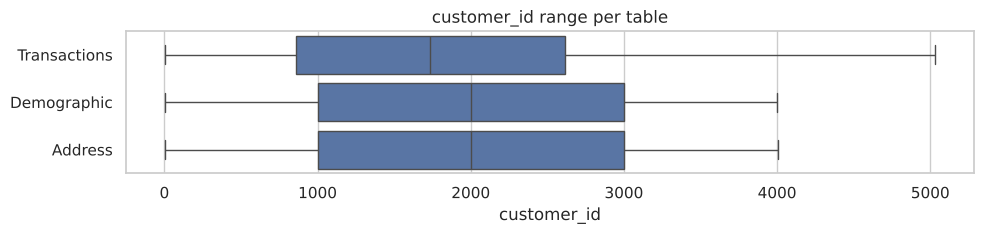

In [23]:
fig, ax = plt.subplots(figsize=(10, 2.5))
sns.boxplot(
    data=pd.concat([
        transactions[["customer_id"]].assign(table="Transactions"),
        demographic[["customer_id"]].assign(table="Demographic"),
        address[["customer_id"]].assign(table="Address"),
    ]),
    x="customer_id", y="table", ax=ax,
)
ax.set(title="customer_id range per table", ylabel="")
plt.tight_layout()
plt.show()

In [24]:
log("Transactions", "customer_id", "Integrity", "customer_id 5034 not in Demographic table",
    tx_not_in_demo.sum(), "Exclude from customer-level analysis; ask client for the missing record")
log("CustomerAddress / Demographic", "customer_id", "Integrity", "Customers present in only one of the two tables",
    demo_not_in_addr.sum() + addr_not_in_demo.sum(), "Inner-join for analysis; report mismatches to client")

## 7. Quick look at relationships

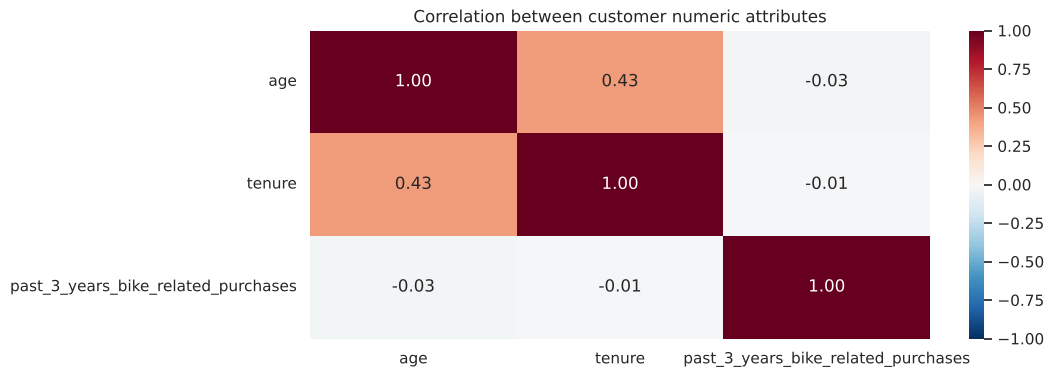

In [25]:
num = demographic.loc[~too_old, ["age", "tenure", "past_3_years_bike_related_purchases"]]
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Correlation between customer numeric attributes")
plt.show()

Age and tenure have a moderate correlation (r = 0.43): older customers have been with the company longer, as expected. Bike purchases are unrelated to either.

## 8. Issue log

In [26]:
issue_log = (pd.DataFrame(issues)
               .sort_values(["table", "dimension"])
               .reset_index(drop=True))
issue_log.index += 1
pd.set_option("display.max_colwidth", 90)
issue_log

,table,column,dimension,issue,rows_affected,recommendation
1,CustomerAddress,state,Consistency,Full state names mixed with abbreviations,168,"Map New South Wales -> NSW, Victoria -> VIC"
2,CustomerAddress / Demographic,customer_id,Integrity,Customers present in only one of the two tables,7,Inner-join for analysis; report mismatches to client
3,CustomerDemographic,job_industry_category,Accuracy,Typo 'Argiculture',113,Rename to 'Agriculture'
4,CustomerDemographic,DOB,Accuracy,"Implausible DOB (born 1843, age > 170)",1,Treat as missing and confirm with client
5,CustomerDemographic,job_industry_category,Completeness,Missing industry,656,Label as 'Unknown'; ask client to capture at sign-up
6,CustomerDemographic,job_title,Completeness,Missing job title,506,Label as 'Unknown'
7,CustomerDemographic,last_name,Completeness,Missing last name,125,Not needed for modelling; flag for the CRM team
8,CustomerDemographic,"DOB, tenure",Completeness,DOB and tenure missing (same rows),87,Exclude from age-based segmentation or impute with the median by segment
9,CustomerDemographic,gender,Completeness,Gender 'U' (unknown),88,Keep as 'Unknown'
10,CustomerDemographic,gender,Consistency,Gender coded as F / Femal / M alongside Female / Male,3,Map to Female / Male


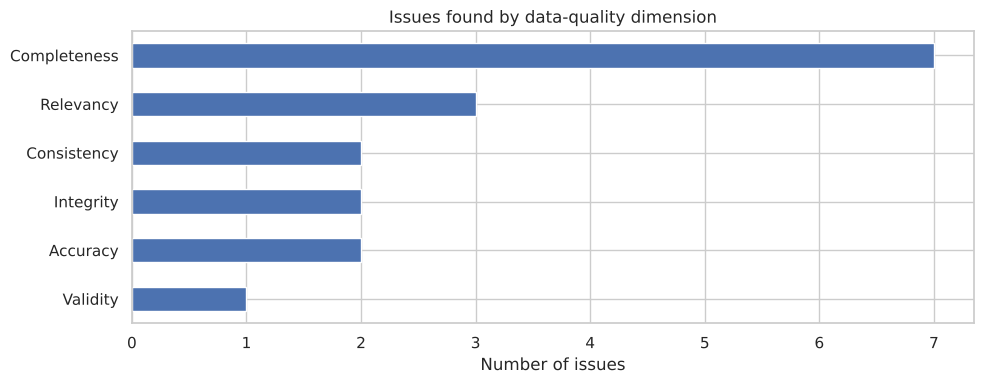

In [27]:
ax = issue_log.groupby("dimension").size().sort_values().plot.barh(color="C0")
ax.set(title="Issues found by data-quality dimension", xlabel="Number of issues", ylabel="")
plt.tight_layout()
plt.show()

## 9. Applying the fixes

The recommended fixes are applied below, producing analysis-ready tables. Rows are only removed when they cannot be used (cancelled orders, deceased customers, IDs with no match). Other gaps are labelled as Unknown so no sales data is lost.

In [28]:
demo_clean = (
    demographic
    .drop(columns=["default"])
    .assign(
        gender=lambda d: d["gender"].replace({"F": "Female", "Femal": "Female", "M": "Male", "U": "Unknown"}),
        job_industry_category=lambda d: d["job_industry_category"].replace({"Argiculture": "Agriculture"}).fillna("Unknown"),
        job_title=lambda d: d["job_title"].fillna("Unknown"),
        DOB=dob.mask(too_old),
        age=lambda d: d["age"].mask(too_old),
    )
    .query("deceased_indicator == 'N'")
)

address_clean = address.assign(state=address["state"].replace({"New South Wales": "NSW", "Victoria": "VIC"}))

tx_clean = (
    transactions
    .query("order_status == 'Approved'")
    .loc[lambda d: d["customer_id"].isin(demo_clean["customer_id"])]
    .assign(online_order=lambda d: d["online_order"].map({1.0: "Online", 0.0: "In store"}).fillna("Unknown"))
)

summary = pd.DataFrame({
    "before": [len(transactions), len(demographic), len(address)],
    "after": [len(tx_clean), len(demo_clean), len(address_clean)],
}, index=["Transactions", "CustomerDemographic", "CustomerAddress"])
summary["removed"] = summary["before"] - summary["after"]
summary

,before,after,removed
Transactions,20000,19810,190
CustomerDemographic,4000,3998,2
CustomerAddress,3999,3999,0


In [29]:
print("Gender:", demo_clean["gender"].value_counts().to_dict())
print("State: ", address_clean["state"].value_counts().to_dict())

Gender: {'Female': 2038, 'Male': 1872, 'Unknown': 88}
State:  {'NSW': 2140, 'VIC': 1021, 'QLD': 838}


## 10. Summary for the client

The data can be used, but several issues should be fixed before building a customer targeting model:

- Completeness: about 16% of customers have no industry and 13% no job title. 197 transactions have no product details and 87 customers have no date of birth or tenure.
- Consistency: gender and state use mixed codes (F, Femal and Female; NSW and New South Wales), which would split the same group in two in any summary.
- Accuracy: one customer was born in 1843, the `default` column contains only unreadable strings, and one industry is misspelled.
- Integrity: one customer ID in the transactions has no customer record, and the demographic and address tables do not fully match.
- Relevancy: cancelled orders and deceased customers should be excluded from targeting.

**Recommendations:** use fixed lists (dropdowns) for gender, state and industry at data entry, validate dates of birth, keep customer IDs in sync across systems, and drop or fix the `default` field at the source.